In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/cajjster/data_files/main/online_sales.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


In [4]:
df.groupby("Country")["Country"].count().sort_values(ascending=False)

Country
Germany        9495
France         8557
Spain          2533
Netherlands    2371
Belgium        2069
Switzerland    2002
Portugal       1519
Australia      1259
Norway         1086
Italy           803
Sweden          462
Name: Country, dtype: int64

In [5]:
df.Country.value_counts()

Country
Germany        9495
France         8557
Spain          2533
Netherlands    2371
Belgium        2069
Switzerland    2002
Portugal       1519
Australia      1259
Norway         1086
Italy           803
Sweden          462
Name: count, dtype: int64

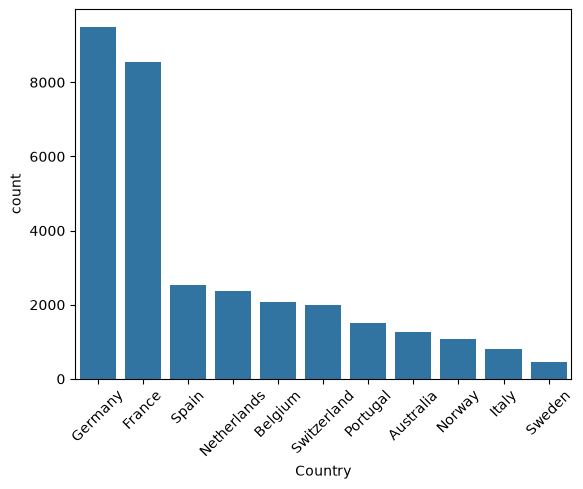

In [6]:
sns.countplot(data=df, x="Country",order=df["Country"].value_counts().index)
plt.xticks(rotation=45, ha ="center")
plt.show()

<Axes: xlabel='Country', ylabel='count'>

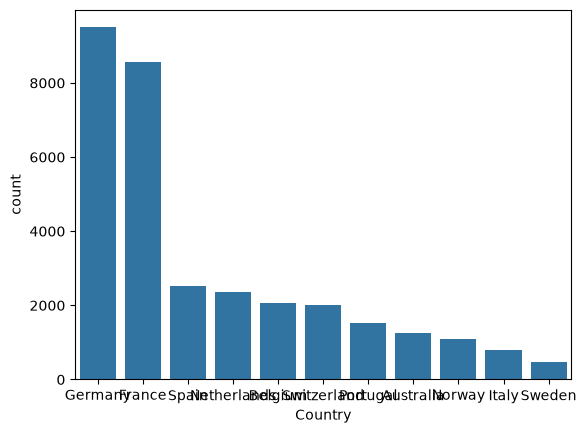

In [7]:
sns.countplot(data=df, x="Country",order=df["Country"].value_counts().index)


## `groupby()` using any aggregation method

`count()`: Count the number of non-NA/null values in each group.<br>
`sum()`: Compute the sum of each group.<br>
`mean()`: Compute the mean of each group.<br>
`median()`: Compute the median of each group.<br>
`min()`: Compute the minimum of each group.<br>
`max()`: Compute the maximum of each group.<br>
`std()`: Compute the standard deviation of each group.<br>
`var()`: Compute the variance of each group.<br>
`first()`: Compute the first value of each group.<br>
`last()`: Compute the last value of each group.<br>
`describe()`: Generate descriptive statistics of each group.<br>
`apply()`: Apply a custom function to each group.<br>

In [8]:
df.groupby("Country")["Quantity"].sum()
df.groupby("Country")["Quantity"].sum().to_frame() #MAKE IT INTO A DF
df.groupby("Country")[["Quantity"]].sum()#MAKE IT INTO A DF

,Quantity
Country,
Australia,83653
Belgium,23152
France,110480
Germany,117448
Italy,7999
Netherlands,200128
Norway,19247
Portugal,16180
Spain,26824


In [9]:
df.groupby("Country")[["UnitPrice"]].mean()

,UnitPrice
Country,
Australia,3.220612
Belgium,3.644335
France,5.028864
Germany,3.966930
Italy,4.831121
Netherlands,2.738317
Norway,6.012026
Portugal,8.582976
Spain,4.987544


In [10]:
df.groupby("Country")[["UnitPrice"]].median()

,UnitPrice
Country,
Australia,1.79
Belgium,1.95
France,1.79
Germany,1.95
Italy,2.55
Netherlands,1.45
Norway,2.08
Portugal,1.65
Spain,2.08


In [11]:
df.groupby("Country")[["UnitPrice"]].agg(["mean","median"])

UnitPrice       
                 mean median
Country                     
Australia    3.220612   1.79
Belgium      3.644335   1.95
France       5.028864   1.79
Germany      3.966930   1.95
Italy        4.831121   2.55
Netherlands  2.738317   1.45
Norway       6.012026   2.08
Portugal     8.582976   1.65
Spain        4.987544   2.08
Sweden       3.910887   1.65
Switzerland  3.403442   1.69

In [12]:
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 


df.groupby("Country")[["UnitPrice"]].describe() 

# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 
# INSANE PAY ATTENTION 


UnitPrice                                                      
                count      mean        std   min   25%   50%   75%      max
Country                                                                    
Australia      1259.0  3.220612  12.455584  0.00  1.25  1.79  3.75   350.00
Belgium        2069.0  3.644335   4.244522  0.12  1.25  1.95  4.15    39.95
France         8557.0  5.028864  79.909126  0.00  1.25  1.79  3.75  4161.06
Germany        9495.0  3.966930  16.549026  0.00  1.25  1.95  3.75   599.50
Italy           803.0  4.831121  11.812512  0.12  1.57  2.55  4.95   300.00
Netherlands    2371.0  2.738317   6.311412  0.00  0.85  1.45  2.55   206.40
Norway         1086.0  6.012026  30.558815  0.00  1.25  2.08  4.95   700.00
Portugal       1519.0  8.582976  71.379996  0.12  1.25  1.65  3.25  1241.98
Spain          2533.0  4.987544  41.003162  0.00  1.25  2.08  4.25  1715.85
Sweden          462.0  3.910887   8.285089  0.19  0.83  1.65  2.95    40.00
Switzerland    2002.0  3.403442   5.389581  0.00  1.25  1.69  3.75    40.00

How `groupby()` and `sns.barplot()` are two sides of the same coin

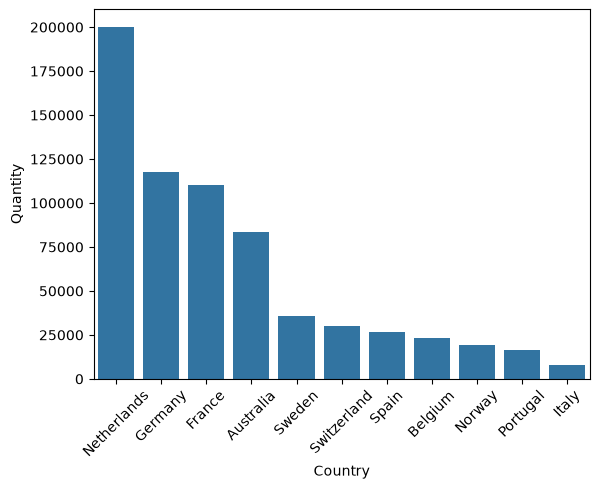

In [16]:
order = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).index
ax = sns.barplot(data=df,x="Country",y="Quantity",estimator="sum", errorbar=None,order=order)
ax.tick_params(axis="x", rotation=45)
plt.show()

In [18]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    32156 non-null  str           
 1   StockCode    32156 non-null  str           
 2   Description  32156 non-null  str           
 3   Quantity     32156 non-null  int64         
 4   InvoiceDate  32156 non-null  datetime64[us]
 5   UnitPrice    32156 non-null  float64       
 6   CustomerID   31926 non-null  float64       
 7   Country      32156 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 2.0 MB


In [ ]:
df.groupby("InvoiceDate")["Quantity"].count() #THIS IS DATES HAVE TO BE EXACT SAME TO THE SECOND

InvoiceDate
2010-12-01 08:45:00    20
2010-12-01 10:03:00    14
2010-12-01 11:27:00     2
2010-12-01 13:04:00    15
2010-12-01 13:24:00    73
                       ..
2011-12-09 10:13:00    18
2011-12-09 11:59:00    13
2011-12-09 12:09:00    13
2011-12-09 12:16:00    38
2011-12-09 12:50:00    15
Name: Quantity, Length: 1724, dtype: int64

In [ ]:
df.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["Quantity"].sum() #ME for month end MS for month start

InvoiceDate
2010-12-31    30836
2011-01-31    58005
2011-02-28    38684
2011-03-31    54437
2011-04-30    14611
2011-05-31    60684
2011-06-30    63124
2011-07-31    34713
2011-08-31    69865
2011-09-30    64119
2011-10-31    90054
2011-11-30    71136
2011-12-31    20805
Freq: ME, Name: Quantity, dtype: int64

In [ ]:
df.groupby(pd.Grouper(key="InvoiceDate", freq="QE"))["Quantity"].sum()

InvoiceDate
2010-12-31     30836
2011-03-31    151126
2011-06-30    138419
2011-09-30    168697
2011-12-31    181995
Freq: QE-DEC, Name: Quantity, dtype: int64

In [40]:
df.groupby(["Country",pd.Grouper(key="InvoiceDate", freq="QE")])["Quantity"].sum().unstack(-2)

Country,Australia,Belgium,France,Germany,Italy,Netherlands,Norway,Portugal,Spain,Sweden,Switzerland
InvoiceDate,,,,,,,,,,,
2010-12-31,454,1755,4978,6723,293,6811,3582,945,867,3714,714
2011-03-31,24632,3656,23095,20664,1891,51605,385,4262,7243,8609,5084
2011-06-30,25163,5242,21437,25991,971,41436,2009,1681,3958,3543,6988
2011-09-30,21798,5696,26516,29579,1198,46426,5852,3349,7717,11658,8908
2011-12-31,11606,6803,34454,34491,3646,53850,7419,5943,7039,8113,8631


## Create and use your own functions with `apply()`

In [42]:
df.groupby("Country").apply(lambda x: (x["Quantity"] * x["UnitPrice"]).sum())

Country
Australia      137077.27
Belgium         40910.96
France         197403.90
Germany        221698.21
Italy           16890.51
Netherlands    284661.54
Norway          35163.46
Portugal        29367.02
Spain           54774.58
Sweden          36595.91
Switzerland     56385.35
dtype: float64

In [44]:
def calc_rev(x):
    return (x["Quantity"] * x["UnitPrice"])

df.groupby("Country").apply(calc_rev)
## thsi is hard coded for dinamic ones we can use 

def calc_product_sum(qty_col, price_col):
    def _calc(x):
        return (x[qty_col] * x[price_col]).sum()
    return _calc

df.groupby("Country").apply(calc_product_sum("Quantity", "UnitPrice"))

Country
Australia      137077.27
Belgium         40910.96
France         197403.90
Germany        221698.21
Italy           16890.51
Netherlands    284661.54
Norway          35163.46
Portugal        29367.02
Spain           54774.58
Sweden          36595.91
Switzerland     56385.35
dtype: float64

## Double Groupby and `sns.barplot` with `hue`are two sides of the same coin

In [46]:
df = pd.read_csv("https://raw.githubusercontent.com/cajjster/data_files/main/vending_machine_sales_.csv")
df.head()

,Location,Machine,Product,Category,MPrice,MQty,LineTotal,TransTotal
0,Brunswick Sq Mall,BSQ Mall x1366 - ATT,Red Bull - Energy Drink - Sugar Free,Carbonated,3.5,1,3.5,3.5
1,Brunswick Sq Mall,BSQ Mall x1366 - ATT,Red Bull - Energy Drink - Sugar Free,Carbonated,3.5,1,3.5,5.0
2,Brunswick Sq Mall,BSQ Mall x1366 - ATT,Takis - Hot Chilli Pepper & Lime,Food,1.5,1,1.5,5.0
3,Brunswick Sq Mall,BSQ Mall x1366 - ATT,Takis - Hot Chilli Pepper & Lime,Food,1.5,1,1.5,1.5
4,Brunswick Sq Mall,BSQ Mall x1366 - ATT,Red Bull - Energy Drink - Sugar Free,Carbonated,3.5,1,3.5,3.5


In [49]:
df.groupby(["Location","Category"])["TransTotal"].sum().unstack(-1)

Category,Carbonated,Food,Non Carbonated,Water
Location,,,,
Brunswick Sq Mall,719.00,1493.0,627.75,698.25
EB Public Library,1152.75,4287.0,1202.00,598.75
Earle Asphalt,152.00,1647.0,91.00,46.50
GuttenPlans,3267.00,3511.5,1018.00,NaN


<Axes: xlabel='Location', ylabel='TransTotal'>

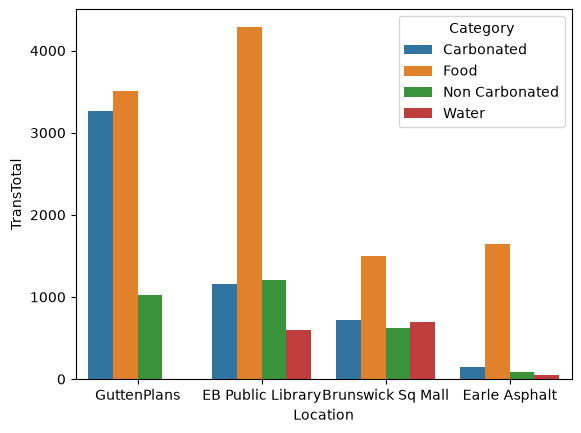

In [53]:
order = df.groupby("Location")["TransTotal"].sum().sort_values(ascending=False).index

sns.barplot(data=df, x="Location", y="TransTotal", errorbar=None, estimator="sum",hue="Category", order = order)